# Statistical Significance Tests

Pairwise Wilcoxon signed-rank tests across 20 seeds for all 5 models.

- Primary metric: AUC
- Secondary: FAR, Event Sensitivity
- Output: p-value matrix table + LaTeX code

In [2]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.stats import wilcoxon
import warnings
warnings.filterwarnings('ignore')

RESULTS_DIRS = {
    'PSD+LDA':        r'D:\seizure_results\psd_lda\results.json',
    '1D-CNN':         r'D:\seizure_results\1dcnn\results.json',
    'EEGNet':         r'D:\seizure_results\eegnet\results.json',
    'TCN':            r'D:\seizure_results\tcn\results.json',
    'EEG-Conformer':  r'D:\seizure_results\eeg_conformer\results.json',
}

# Metric key in results.json → display name
METRICS = {
    'test_auc':          'AUC',
    'far':               'FAR (/h)',
    'event_sensitivity': 'Event Sensitivity',
    'test_sen':          'Sensitivity (win)',
    'test_f1':           'F1',
}

print('Loading results...')

Loading results...


In [4]:
# Load all results into a dict: model_name -> list of per-seed dicts
data = {}
for model, path in RESULTS_DIRS.items():
    try:
        with open(path) as f:
            data[model] = json.load(f)
        print(f'  {model}: {len(data[model])} seeds loaded')
    except FileNotFoundError:
        print(f'  {model}: NOT FOUND at {path}')

models = list(data.keys())
n_seeds = len(next(iter(data.values())))
print(f'\n{len(models)} models, {n_seeds} seeds each')

  PSD+LDA: 20 seeds loaded
  1D-CNN: 20 seeds loaded
  EEGNet: 20 seeds loaded
  TCN: 20 seeds loaded
  EEG-Conformer: 20 seeds loaded

5 models, 20 seeds each


In [3]:
# ── Summary Table (mean ± std for all models × metrics) ──
rows = []
for model in models:
    row = {'Model': model}
    for key, label in METRICS.items():
        vals = [r[key] for r in data[model] if key in r]
        if vals:
            row[label] = f'{np.mean(vals):.4f} ± {np.std(vals, ddof=1):.4f}'
        else:
            row[label] = 'N/A'
    rows.append(row)

summary_df = pd.DataFrame(rows).set_index('Model')
print('\n=== Summary Table (mean ± std, n=20 seeds) ===')
display(summary_df)


=== Summary Table (mean ± std, n=20 seeds) ===


,AUC,FAR (/h),Event Sensitivity,Sensitivity (win),F1
Model,,,,,
PSD+LDA,0.5394 ± 0.0808,4.9631 ± 2.9060,0.9458 ± 0.0954,0.4554 ± 0.2577,0.4683 ± 0.1606
1D-CNN,0.5650 ± 0.0754,4.1845 ± 2.8217,0.8378 ± 0.2043,0.4378 ± 0.2360,0.4667 ± 0.1802
EEGNet,0.5642 ± 0.0718,4.7483 ± 2.7058,0.9229 ± 0.1419,0.4691 ± 0.2532,0.4738 ± 0.1669
TCN,0.5735 ± 0.0586,4.6962 ± 2.5767,0.9107 ± 0.1065,0.4836 ± 0.2264,0.4966 ± 0.1578
EEG-Conformer,0.5517 ± 0.0832,5.0187 ± 2.8333,0.8843 ± 0.1469,0.4782 ± 0.2554,0.4873 ± 0.1814


In [4]:
# ── Pairwise Wilcoxon Signed-Rank Tests ──
# For each metric, compute n×n p-value matrix.
# wilcoxon(a, b) tests H0: a and b come from same distribution.
# We test per-seed paired differences.

def pairwise_wilcoxon(data, models, metric_key):
    """
    Returns (n_models × n_models) DataFrame of p-values.
    p[i,j] = p-value for wilcoxon(model_i_scores, model_j_scores).
    Diagonal is NaN.
    """
    n = len(models)
    pmat = np.full((n, n), np.nan)
    scores = {}
    for m in models:
        scores[m] = np.array([r[metric_key] for r in data[m] if metric_key in r])

    for i, mi in enumerate(models):
        for j, mj in enumerate(models):
            if i == j:
                continue
            a, b = scores[mi], scores[mj]
            min_len = min(len(a), len(b))
            try:
                _, p = wilcoxon(a[:min_len], b[:min_len], alternative='two-sided')
            except ValueError:
                p = 1.0
            pmat[i, j] = p

    return pd.DataFrame(pmat, index=models, columns=models)

pval_tables = {}
for key, label in METRICS.items():
    pval_tables[label] = pairwise_wilcoxon(data, models, key)
    print(f'\n=== {label} — Pairwise Wilcoxon p-values ===')
    display(pval_tables[label].round(4))


=== AUC — Pairwise Wilcoxon p-values ===


,PSD+LDA,1D-CNN,EEGNet,TCN,EEG-Conformer
PSD+LDA,NaN,0.1769,0.0696,0.0441,0.4091
1D-CNN,0.1769,NaN,0.8983,0.4980,0.2774
EEGNet,0.0696,0.8983,NaN,0.1893,0.4749
TCN,0.0441,0.4980,0.1893,NaN,0.0973
EEG-Conformer,0.4091,0.2774,0.4749,0.0973,NaN



=== FAR (/h) — Pairwise Wilcoxon p-values ===


,PSD+LDA,1D-CNN,EEGNet,TCN,EEG-Conformer
PSD+LDA,NaN,0.2455,0.7012,0.8124,0.8721
1D-CNN,0.2455,NaN,0.0897,0.2305,0.3488
EEGNet,0.7012,0.0897,NaN,0.8124,0.7285
TCN,0.8124,0.2305,0.8124,NaN,0.7841
EEG-Conformer,0.8721,0.3488,0.7285,0.7841,NaN



=== Event Sensitivity — Pairwise Wilcoxon p-values ===


,PSD+LDA,1D-CNN,EEGNet,TCN,EEG-Conformer
PSD+LDA,NaN,0.0251,0.6740,0.1299,0.0414
1D-CNN,0.0251,NaN,0.0690,0.0662,0.5292
EEGNet,0.6740,0.0690,NaN,0.5335,0.3449
TCN,0.1299,0.0662,0.5335,NaN,0.3878
EEG-Conformer,0.0414,0.5292,0.3449,0.3878,NaN



=== Sensitivity (win) — Pairwise Wilcoxon p-values ===


,PSD+LDA,1D-CNN,EEGNet,TCN,EEG-Conformer
PSD+LDA,NaN,0.5958,0.8983,0.4209,0.7475
1D-CNN,0.5958,NaN,0.6477,0.0107,0.5459
EEGNet,0.8983,0.6477,NaN,0.8983,0.8408
TCN,0.4209,0.0107,0.8983,NaN,0.4939
EEG-Conformer,0.7475,0.5459,0.8408,0.4939,NaN



=== F1 — Pairwise Wilcoxon p-values ===


,PSD+LDA,1D-CNN,EEGNet,TCN,EEG-Conformer
PSD+LDA,NaN,0.9563,0.5459,0.2774,0.7172
1D-CNN,0.9563,NaN,0.8695,0.0073,0.7012
EEGNet,0.5459,0.8695,NaN,0.5217,0.7841
TCN,0.2774,0.0073,0.5217,NaN,0.3488
EEG-Conformer,0.7172,0.7012,0.7841,0.3488,NaN


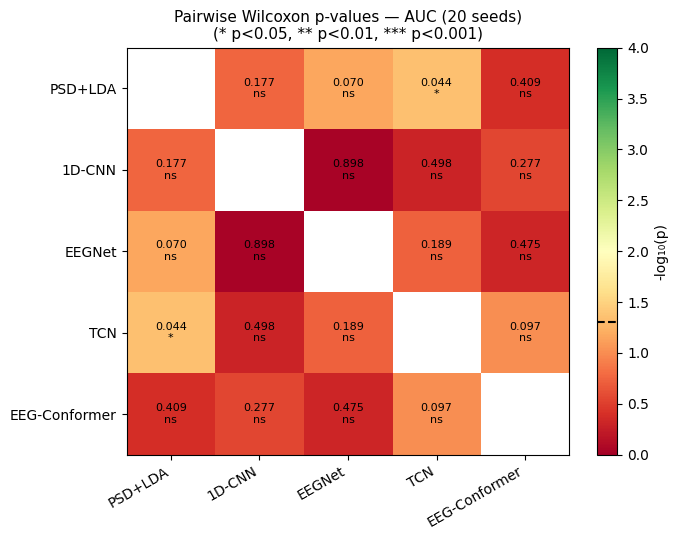

In [5]:
# ── Heatmap: AUC p-value matrix ──
import matplotlib.ticker as ticker

def plot_pval_heatmap(pmat_df, title, alpha=0.05, save_path=None):
    n = len(pmat_df)
    vals = pmat_df.values.copy()

    fig, ax = plt.subplots(figsize=(7, 5.5))
    # Use log scale for colours so small p-values pop
    log_vals = np.where(np.isnan(vals), np.nan, -np.log10(np.clip(vals, 1e-10, 1)))

    im = ax.imshow(log_vals, cmap='RdYlGn', aspect='auto', vmin=0, vmax=4)
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label('-log₁₀(p)', fontsize=10)
    cbar.ax.axhline(-np.log10(alpha), color='black', linewidth=1.5, linestyle='--')

    ax.set_xticks(range(n))
    ax.set_yticks(range(n))
    ax.set_xticklabels(pmat_df.columns, rotation=30, ha='right', fontsize=10)
    ax.set_yticklabels(pmat_df.index, fontsize=10)

    # Annotate cells
    for i in range(n):
        for j in range(n):
            if np.isnan(vals[i, j]):
                continue
            p = vals[i, j]
            stars = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
            txt = f'{p:.3f}\n{stars}'
            color = 'white' if log_vals[i, j] > 2 else 'black'
            ax.text(j, i, txt, ha='center', va='center', fontsize=8, color=color)

    ax.set_title(f'{title}\n(* p<0.05, ** p<0.01, *** p<0.001)', fontsize=11)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=200, bbox_inches='tight')
    plt.show()

import os
os.makedirs(r'D:\seizure_results\figures', exist_ok=True)

plot_pval_heatmap(
    pval_tables['AUC'],
    'Pairwise Wilcoxon p-values — AUC (20 seeds)',
    save_path=r'D:\seizure_results\figures\wilcoxon_auc.png'
)

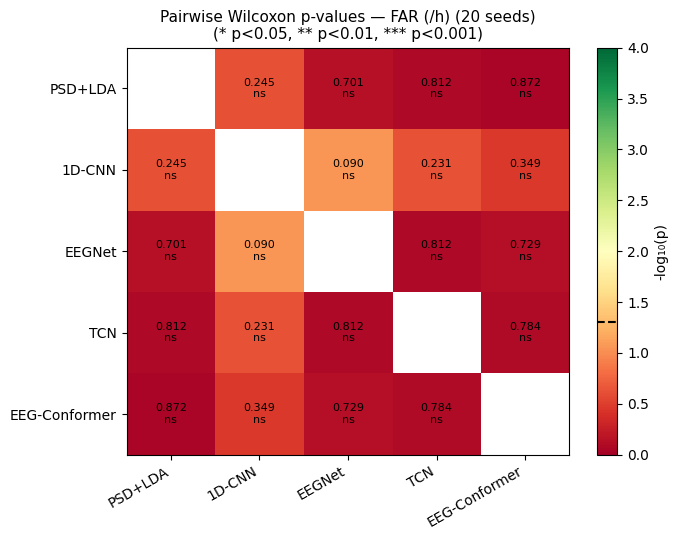

In [6]:
# FAR heatmap (lower FAR is better)
plot_pval_heatmap(
    pval_tables['FAR (/h)'],
    'Pairwise Wilcoxon p-values — FAR (/h) (20 seeds)',
    save_path=r'D:\seizure_results\figures\wilcoxon_far.png'
)

In [7]:
# ── Effect size: Cohen's d (paired) for AUC ──
# Useful to report alongside p-values in the paper.

def cohens_d_paired(a, b):
    diff = np.array(a) - np.array(b)
    return diff.mean() / (diff.std(ddof=1) + 1e-12)

auc_key = 'test_auc'
auc_scores = {m: np.array([r[auc_key] for r in data[m]]) for m in models}

print('\nCohen\'s d (paired) for AUC — row model minus column model')
d_mat = pd.DataFrame(index=models, columns=models, dtype=float)
for mi in models:
    for mj in models:
        if mi == mj:
            d_mat.loc[mi, mj] = np.nan
        else:
            n = min(len(auc_scores[mi]), len(auc_scores[mj]))
            d_mat.loc[mi, mj] = cohens_d_paired(auc_scores[mi][:n], auc_scores[mj][:n])
display(d_mat.round(3))


Cohen's d (paired) for AUC — row model minus column model


,PSD+LDA,1D-CNN,EEGNet,TCN,EEG-Conformer
PSD+LDA,NaN,-0.331,-0.459,-0.509,-0.196
1D-CNN,0.331,NaN,0.011,-0.136,0.230
EEGNet,0.459,-0.011,NaN,-0.223,0.211
TCN,0.509,0.136,0.223,NaN,0.376
EEG-Conformer,0.196,-0.230,-0.211,-0.376,NaN


In [8]:
# ── LaTeX output for paper ──
# Table 1: Summary (mean ± std)

col_order = ['AUC', 'Sensitivity (win)', 'Event Sensitivity', 'FAR (/h)', 'F1']
col_order = [c for c in col_order if c in summary_df.columns]

print('% ── LaTeX Table: Cross-Patient Results (mean ± std) ──')
print(r'\begin{table}[htbp]')
print(r'\centering')
print(r'\caption{Cross-patient (PI) results on CHB-MIT (mean $\pm$ std, $n=20$ seeds)}')
print(r'\label{tab:pi_results}')
ncols = len(col_order)
print(r'\begin{tabular}{l' + 'c' * ncols + r'}')
print(r'\toprule')
header = ' & '.join(['Model'] + col_order) + r' \\'
print(header)
print(r'\midrule')
for model in models:
    cells = [model]
    for c in col_order:
        cells.append(summary_df.loc[model, c] if c in summary_df.columns else '-')
    print(' & '.join(cells) + r' \\')
print(r'\bottomrule')
print(r'\end{tabular}')
print(r'\end{table}')

% ── LaTeX Table: Cross-Patient Results (mean ± std) ──
\begin{table}[htbp]
\centering
\caption{Cross-patient (PI) results on CHB-MIT (mean $\pm$ std, $n=20$ seeds)}
\label{tab:pi_results}
\begin{tabular}{lccccc}
\toprule
Model & AUC & Sensitivity (win) & Event Sensitivity & FAR (/h) & F1 \\
\midrule
PSD+LDA & 0.5394 ± 0.0808 & 0.4554 ± 0.2577 & 0.9458 ± 0.0954 & 4.9631 ± 2.9060 & 0.4683 ± 0.1606 \\
1D-CNN & 0.5650 ± 0.0754 & 0.4378 ± 0.2360 & 0.8378 ± 0.2043 & 4.1845 ± 2.8217 & 0.4667 ± 0.1802 \\
EEGNet & 0.5642 ± 0.0718 & 0.4691 ± 0.2532 & 0.9229 ± 0.1419 & 4.7483 ± 2.7058 & 0.4738 ± 0.1669 \\
TCN & 0.5735 ± 0.0586 & 0.4836 ± 0.2264 & 0.9107 ± 0.1065 & 4.6962 ± 2.5767 & 0.4966 ± 0.1578 \\
EEG-Conformer & 0.5517 ± 0.0832 & 0.4782 ± 0.2554 & 0.8843 ± 0.1469 & 5.0187 ± 2.8333 & 0.4873 ± 0.1814 \\
\bottomrule
\end{tabular}
\end{table}


In [9]:
# ── LaTeX output: AUC p-value table ──
print('% ── LaTeX Table: Wilcoxon p-values (AUC) ──')
pmat = pval_tables['AUC']
n = len(models)
print(r'\begin{table}[htbp]')
print(r'\centering')
print(r'\caption{Pairwise Wilcoxon signed-rank test $p$-values for AUC across 20 seeds. * $p<0.05$, ** $p<0.01$, *** $p<0.001$}')
print(r'\label{tab:wilcoxon}')
print(r'\begin{tabular}{l' + 'c' * n + r'}')
print(r'\toprule')
short = [m.replace('EEG-Conformer', 'EEG-Conf.').replace('PSD+LDA', 'LDA') for m in models]
print(' & '.join([''] + short) + r' \\')
print(r'\midrule')
for i, mi in enumerate(models):
    cells = [short[i]]
    for j, mj in enumerate(models):
        if i == j:
            cells.append('—')
        else:
            p = pmat.iloc[i, j]
            stars = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
            cells.append(f'{p:.3f}{stars}')
    print(' & '.join(cells) + r' \\')
print(r'\bottomrule')
print(r'\end{tabular}')
print(r'\end{table}')

% ── LaTeX Table: Wilcoxon p-values (AUC) ──
\begin{table}[htbp]
\centering
\caption{Pairwise Wilcoxon signed-rank test $p$-values for AUC across 20 seeds. * $p<0.05$, ** $p<0.01$, *** $p<0.001$}
\label{tab:wilcoxon}
\begin{tabular}{lccccc}
\toprule
 & LDA & 1D-CNN & EEGNet & TCN & EEG-Conf. \\
\midrule
LDA & — & 0.177ns & 0.070ns & 0.044* & 0.409ns \\
1D-CNN & 0.177ns & — & 0.898ns & 0.498ns & 0.277ns \\
EEGNet & 0.070ns & 0.898ns & — & 0.189ns & 0.475ns \\
TCN & 0.044* & 0.498ns & 0.189ns & — & 0.097ns \\
EEG-Conf. & 0.409ns & 0.277ns & 0.475ns & 0.097ns & — \\
\bottomrule
\end{tabular}
\end{table}


In [7]:
import json, numpy as np
from itertools import combinations

models = ['PSD+LDA', '1D-CNN', 'EEGNet', 'TCN', 'EEG-Conformer']

json_paths = {
    'PSD+LDA':       r'D:\seizure_results\psd_lda\results.json',
    '1D-CNN':        r'D:\seizure_results\1dcnn\results.json',
    'EEGNet':        r'D:\seizure_results\eegnet\results.json',
    'TCN':           r'D:\seizure_results\tcn\results.json',
    'EEG-Conformer': r'D:\seizure_results\eeg_conformer\results.json',
}

model_aucs = {}
for m, path in json_paths.items():
    with open(path) as f:
        data = json.load(f)
    if isinstance(data, list):
        model_aucs[m] = [r['test_auc'] for r in data]
    elif isinstance(data, dict) and 'results' in data:
        model_aucs[m] = [r['test_auc'] for r in data['results']]
    else:
        model_aucs[m] = [v['test_auc'] for v in data.values()]
    print(f"{m}: {len(model_aucs[m])} seeds, mean={np.mean(model_aucs[m]):.4f}")

np.random.seed(0)
N_BOOT = 10000

print("\n=== Bootstrap 95% CI for ΔAUC (row − column) ===")
ci_matrix = {}
for m1 in models:
    ci_matrix[m1] = {}
    for m2 in models:
        if m1 == m2:
            ci_matrix[m1][m2] = None
            continue
        diffs = np.array(model_aucs[m1]) - np.array(model_aucs[m2])
        boot_means = [np.mean(diffs[np.random.randint(0, 20, 20)]) for _ in range(N_BOOT)]
        lo, hi = np.percentile(boot_means, [2.5, 97.5])
        ci_matrix[m1][m2] = (lo, hi)

print("\n=== LaTeX lower triangle (paste into Table 3) ===")
for i, m1 in enumerate(models):
    for j, m2 in enumerate(models):
        if j < i:
            lo, hi = ci_matrix[m1][m2]
            sig = "  ← EXCLUDES ZERO" if (lo > 0 or hi < 0) else ""
            bold = lo > 0 or hi < 0
            cell = f"[{lo:+.3f}, {hi:+.3f}]"
            if bold:
                cell = f"\\textbf{{{cell}}}"
            print(f"  {m1:<20} vs {m2:<20}: {cell}{sig}")

PSD+LDA: 20 seeds, mean=0.5394
1D-CNN: 20 seeds, mean=0.5650
EEGNet: 20 seeds, mean=0.5642
TCN: 20 seeds, mean=0.5735
EEG-Conformer: 20 seeds, mean=0.5517

=== Bootstrap 95% CI for ΔAUC (row − column) ===

=== LaTeX lower triangle (paste into Table 3) ===
  1D-CNN               vs PSD+LDA             : [-0.008, +0.059]
  EEGNet               vs PSD+LDA             : \textbf{[+0.003, +0.048]}  ← EXCLUDES ZERO
  EEGNet               vs 1D-CNN              : [-0.028, +0.028]
  TCN                  vs PSD+LDA             : \textbf{[+0.005, +0.062]}  ← EXCLUDES ZERO
  TCN                  vs 1D-CNN              : [-0.018, +0.035]
  TCN                  vs EEGNet              : [-0.009, +0.026]
  EEG-Conformer        vs PSD+LDA             : [-0.014, +0.039]
  EEG-Conformer        vs 1D-CNN              : [-0.037, +0.012]
  EEG-Conformer        vs EEGNet              : [-0.038, +0.012]
  EEG-Conformer        vs TCN                 : [-0.047, +0.003]
